# Arbre de décision  

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

diabetes_data= pd.read_csv("DB/diabetes.csv")

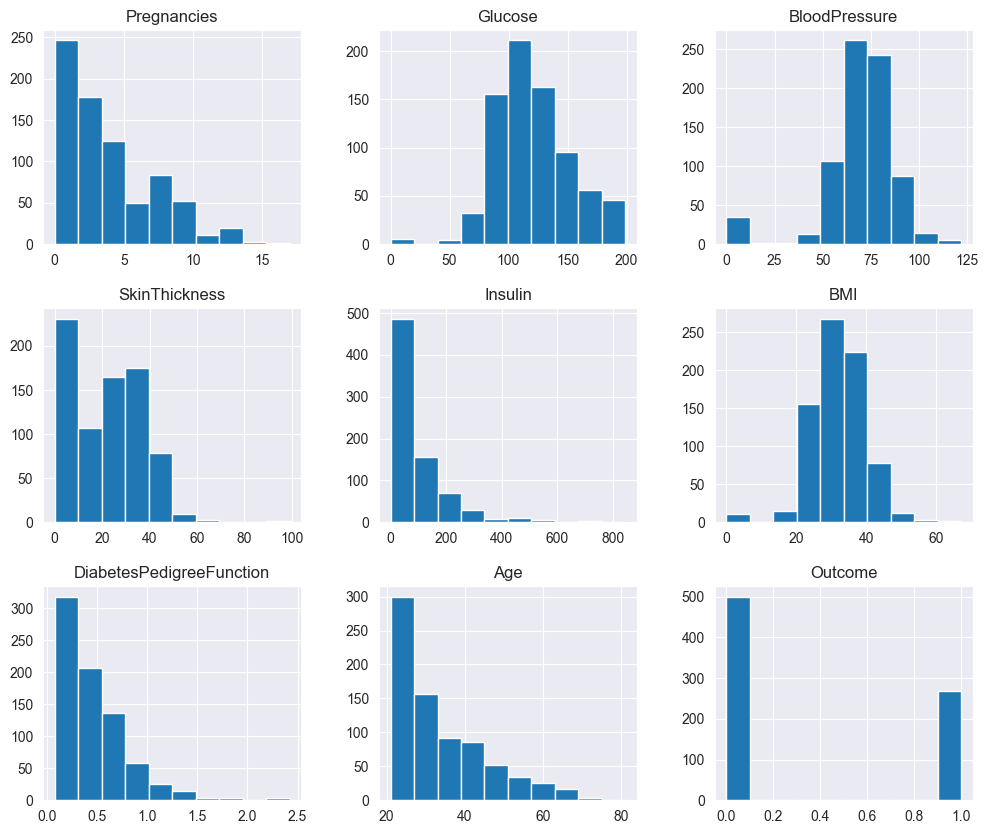

In [2]:
diabetes_data.hist(figsize=(12,10))
plt.show()

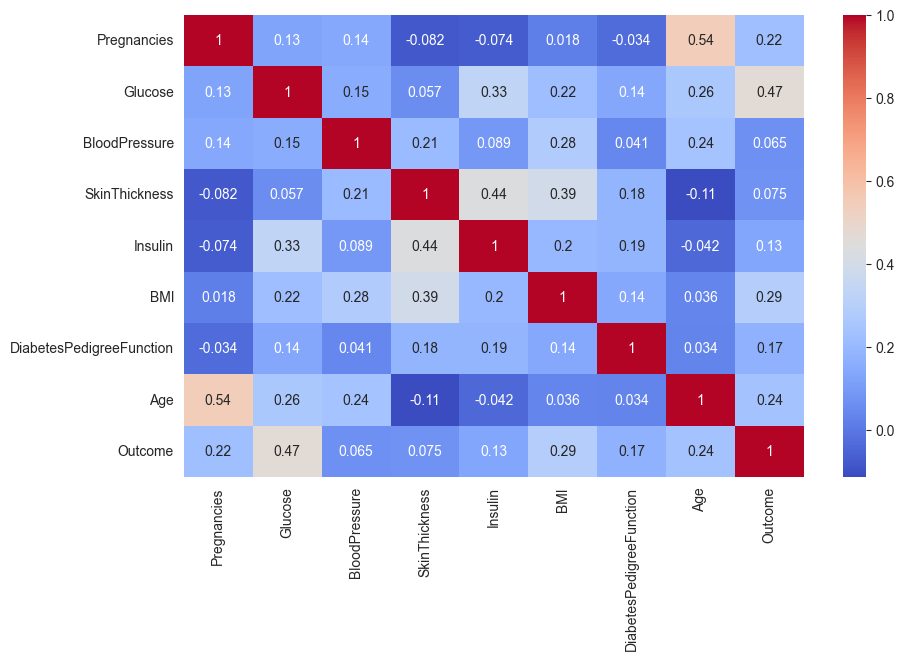

In [3]:
import seaborn as sns
# Heatmap de corrélation
plt.figure(figsize=(10,6))
sns.heatmap(diabetes_data.corr(), annot=True, cmap='coolwarm')
plt.show()

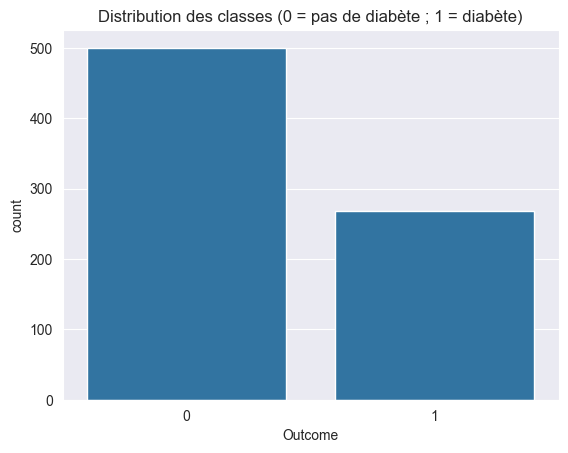

In [4]:
sns.countplot(x='Outcome', data=diabetes_data)
plt.title("Distribution des classes (0 = pas de diabète ; 1 = diabète)")
plt.show()

Classification binaire
Classes possibles :

0 → Non diabétique

1 → Diabétique

In [5]:
feature_cols = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']
X = diabetes_data[feature_cols]
y = diabetes_data['Outcome']

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

In [7]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier()  # gini par défaut
clf = clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

In [8]:
from sklearn.metrics import accuracy_score, confusion_matrix

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Matrice de confusion :\n", confusion_matrix(y_test, y_pred))

Accuracy : 0.70995670995671
Matrice de confusion :
 [[112  39]
 [ 28  52]]


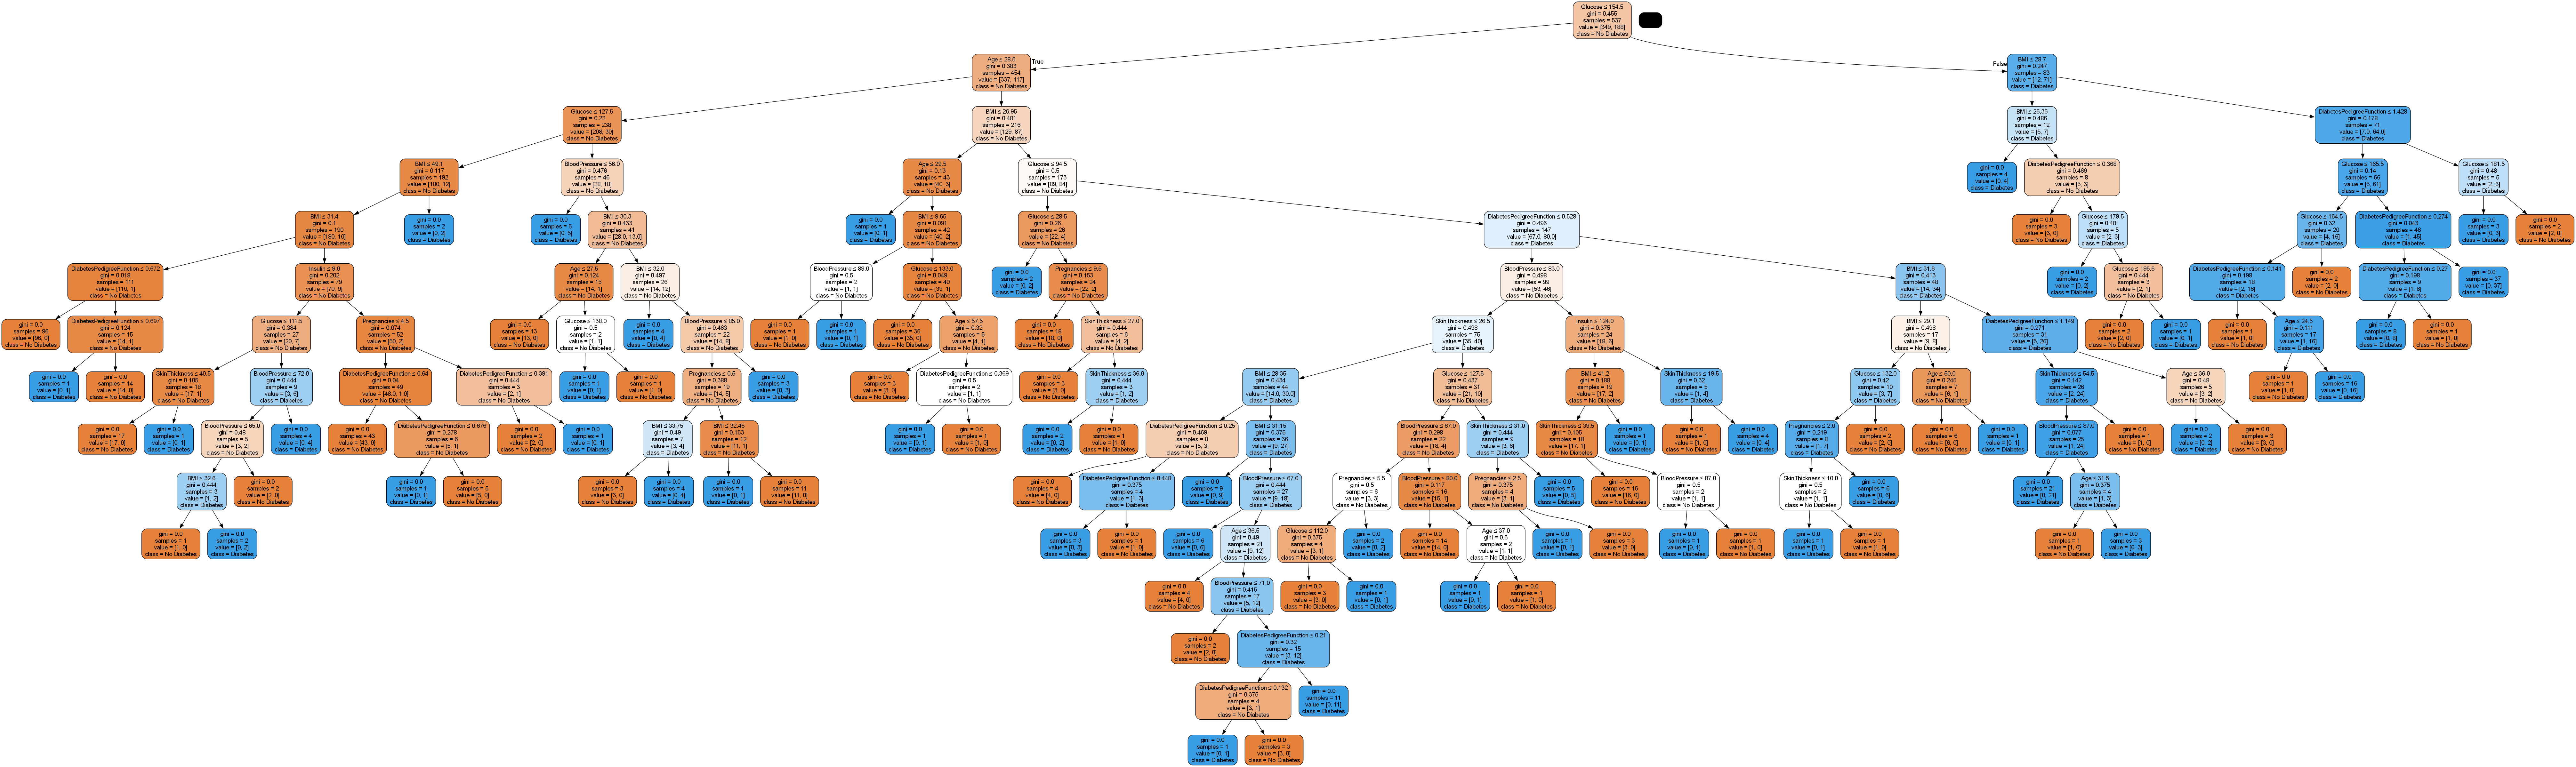

In [9]:
from sklearn.tree import export_graphviz
from io import StringIO
from IPython.display import Image
import pydotplus

dot_data = StringIO()
export_graphviz(
    clf, out_file=dot_data,
    feature_names=feature_cols,
    class_names=['No Diabetes', 'Diabetes'],
    filled=True, rounded=True,
    special_characters=True
)

graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())

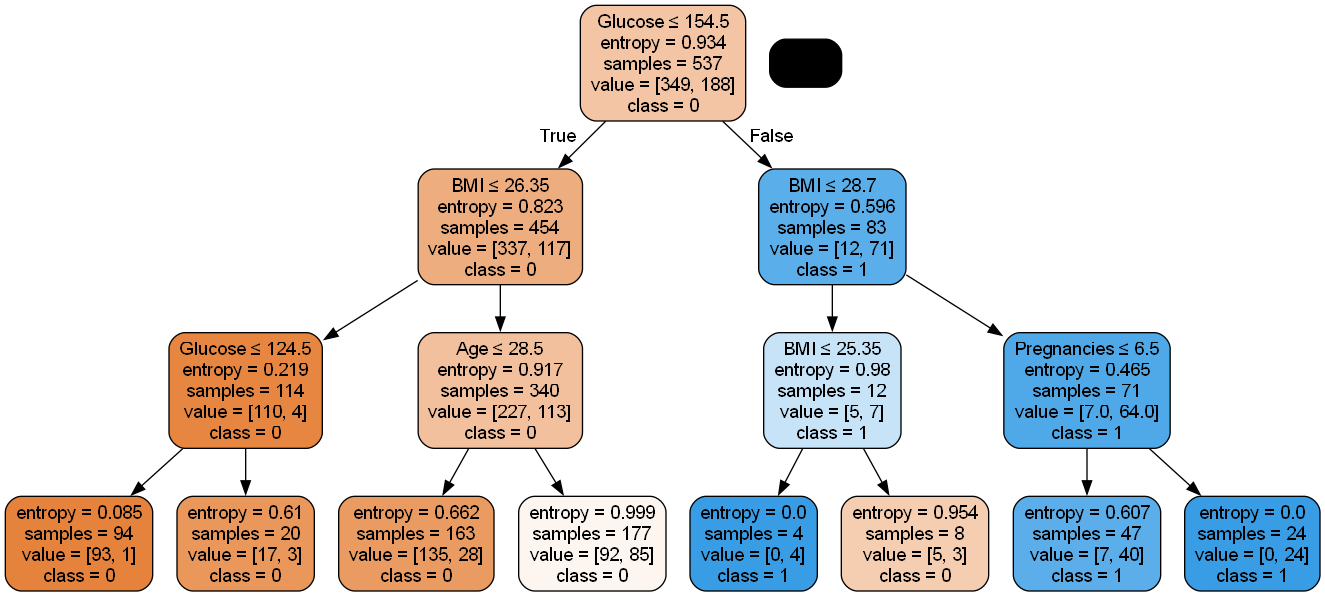

In [10]:
clf2 = DecisionTreeClassifier(criterion="entropy", max_depth=3)
clf2.fit(X_train, y_train)

# Visualisation
dot_data = StringIO()
export_graphviz(clf2, out_file=dot_data,
                filled=True, rounded=True,
                special_characters=True,
                feature_names=feature_cols,
                class_names=['0','1'])

graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())